In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, GlobalAveragePooling1D, Bidirectional, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Reshape
import pickle

In [ ]:
# Combining fake and real news into a single dataframe
fake_news = pd.read_csv('fake_cleaned.csv')
real_news = pd.read_csv('true_cleaned.csv')

fake_news['label'] = 0  
real_news['label'] = 1 
data = pd.concat([fake_news, real_news], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

data['text'] = data['text'].astype(str)
max_words = 10000  # Vocabulary size
max_length = 200   # Maximum words per article

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data["text"])
sequences = tokenizer.texts_to_sequences(data["text"])

# Pad sequences
X = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

y = data["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Evaluating models with classification report
def evaluate_model(model, X_test, y_test, bert=False):
    if bert:
        preds = (model.predict([X_test['input_ids'], X_test['attention_mask']]) > 0.5).astype('int32')
    else:
        preds = (model.predict(X_test) > 0.5).astype('int32')
    print(classification_report(y_test, preds))

In [9]:
# Define LSTM model
def build_lstm_model():
    model = Sequential([
        Embedding(max_words, 128, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


# Define CNN + LSTM model
def build_cnn_lstm_model():
    model = Sequential([
        Embedding(max_words, 128, input_length=max_len),
        Conv1D(64, 5, activation='relu'),
        GlobalAveragePooling1D(),
        Reshape((1, 64)),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


In [10]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,         # Stop if no improvement for 3 epochs
    restore_best_weights=True  # Restore the best model weights
)

lstm_model = build_lstm_model()

history = lstm_model.fit(
    X_train, 
    y_train, 
    epochs=50,  # Increase epochs since EarlyStopping will stop early if needed
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]  # Add EarlyStopping callback
)

Epoch 1/50
1102/1102 [==============================] - 43s 36ms/step - loss: 0.0280 - accuracy: 0.9927 - val_loss: 0.0015 - val_accuracy: 0.9993
Epoch 2/50
1102/1102 [==============================] - 39s 35ms/step - loss: 0.0025 - accuracy: 0.9994 - val_loss: 0.0026 - val_accuracy: 0.9993
Epoch 3/50
1102/1102 [==============================] - 39s 36ms/step - loss: 8.5782e-04 - accuracy: 0.9999 - val_loss: 0.0022 - val_accuracy: 0.9998
Epoch 4/50
1102/1102 [==============================] - 39s 36ms/step - loss: 0.0016 - accuracy: 0.9996 - val_loss: 0.0048 - val_accuracy: 0.9991


In [ ]:
cnn_lstm_model = build_cnn_lstm_model()
history = cnn_lstm_model.fit(
    X_train, 
    y_train, 
    epochs=50,  # Increase epochs since EarlyStopping will stop early if needed
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]  # Add EarlyStopping callback
)

Epoch 1/50
1102/1102 [==============================] - 16s 10ms/step - loss: 0.0765 - accuracy: 0.9664 - val_loss: 0.0149 - val_accuracy: 0.9957
Epoch 2/50
1102/1102 [==============================] - 10s 9ms/step - loss: 0.0043 - accuracy: 0.9988 - val_loss: 0.0161 - val_accuracy: 0.9953
Epoch 3/50
1102/1102 [==============================] - 9s 9ms/step - loss: 7.9407e-04 - accuracy: 0.9998 - val_loss: 0.0198 - val_accuracy: 0.9969
Epoch 4/50
1102/1102 [==============================] - 10s 9ms/step - loss: 0.0010 - accuracy: 0.9998 - val_loss: 0.0374 - val_accuracy: 0.9936


In [12]:
print("LSTM Performance:")
evaluate_model(lstm_model, X_test, y_test)
print("CNN+LSTM Performance:")
evaluate_model(cnn_lstm_model, X_test, y_test)

LSTM Performance:
276/276 [==============================] - 5s 15ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4570
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812

CNN+LSTM Performance:
276/276 [==============================] - 2s 3ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4570
           1       0.99      1.00      1.00      4242

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812



276/276 [==============================] - 4s 15ms/step


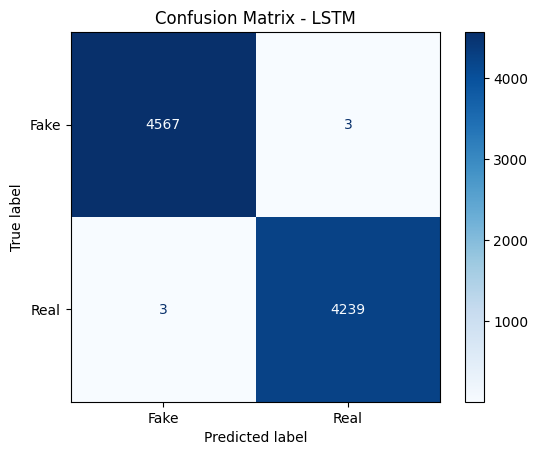

276/276 [==============================] - 1s 2ms/step


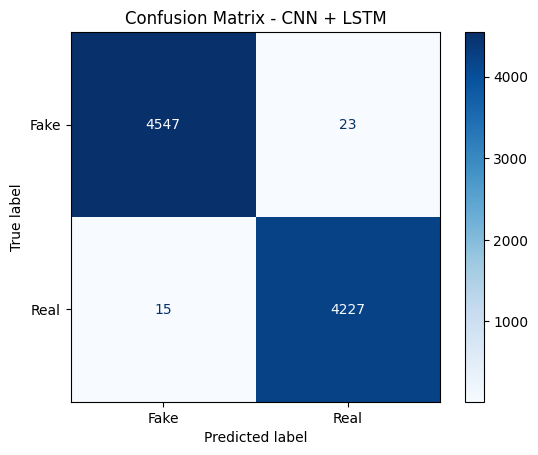

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(model, X_test, y_test, title, is_bert=False):
    y_probs = model.predict(X_test)
    y_pred = (y_probs > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

plot_confusion_matrix(lstm_model, X_test, y_test, "LSTM")
plot_confusion_matrix(cnn_lstm_model, X_test, y_test, "CNN + LSTM")

276/276 [==============================] - 4s 15ms/step


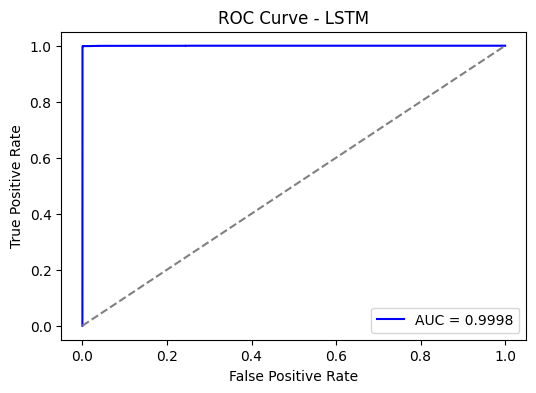

276/276 [==============================] - 1s 2ms/step


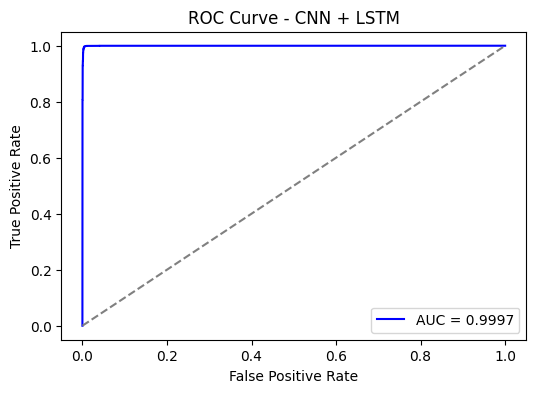

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X_test, y_test, title):
    y_probs = model.predict(X_test)  
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {title}")
    plt.legend(loc="lower right")
    plt.show()

plot_roc_curve(lstm_model, X_test, y_test, "LSTM")
plot_roc_curve(cnn_lstm_model, X_test, y_test, "CNN + LSTM")

## Based off the results above, we can see that the normal LSTM model performs slightly better than the CNN+LSTM model in terms of precision, recall and ROU-AUC score

In [39]:
# Testing the models on a true sentence from the dataset
sample_text=["Head of a conservative Republican faction in the U.S. Congress urged budget restraint in 2019"]
sequence = tokenizer.texts_to_sequences(sample_text)
padded_sample = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

In [ ]:
# Predict with both
lstm_pred = lstm_model.predict(padded_sample)
cnn_lstm_pred = cnn_lstm_model.predict(padded_sample)

lstm_prob = lstm_pred[0][0]  
cnn_lstm_prob = cnn_lstm_pred[0][0]
threshold = 0.5

# LSTM Model Prediction
if lstm_prob >= threshold:
    lstm_result = "Real"
    lstm_confidence = lstm_prob * 100  # Confidence in Real
else:
    lstm_result = "Fake"
    lstm_confidence = (1 - lstm_prob) * 100  # Confidence in Fake

# CNN-LSTM Model Prediction
if cnn_lstm_prob >= threshold:
    cnn_lstm_result = "Real"
    cnn_lstm_confidence = cnn_lstm_prob * 100  # Confidence in Real
else:
    cnn_lstm_result = "Fake"
    cnn_lstm_confidence = (1 - cnn_lstm_prob) * 100  # Confidence in Fake

# Print results
print(f"LSTM Prediction: {lstm_result} (Confidence: {lstm_confidence:.2f}%)")
print(f"CNN-LSTM Prediction: {cnn_lstm_result} (Confidence: {cnn_lstm_confidence:.2f}%)")

1/1 [==============================] - 0s 26ms/step
LSTM Prediction: Real (Confidence: 86.66%)
CNN-LSTM Prediction: Real (Confidence: 80.67%)


### Both models are able to crrectly predict the true sentence as real news 

### To try and improve it's confidence scores, more advanced versions of the models are created.

In [15]:
from tensorflow.keras.layers import LSTM, BatchNormalization, LeakyReLU

def build_improved_lstm_model():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.2)),
        BatchNormalization(),  
        
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.2)),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.5),

        Dense(1, activation='sigmoid') 
    ])
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


In [ ]:
lstm_model_redo = build_improved_lstm_model()

lstm_model_redo.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stopping] 
)

Epoch 1/50
1102/1102 [==============================] - 100s 85ms/step - loss: 0.0269 - accuracy: 0.9924 - val_loss: 0.0081 - val_accuracy: 0.9983
Epoch 2/50
1102/1102 [==============================] - 93s 85ms/step - loss: 0.0113 - accuracy: 0.9973 - val_loss: 0.0226 - val_accuracy: 0.9960
Epoch 3/50
1102/1102 [==============================] - 92s 83ms/step - loss: 0.0053 - accuracy: 0.9988 - val_loss: 0.0094 - val_accuracy: 0.9985
Epoch 4/50
1102/1102 [==============================] - 92s 84ms/step - loss: 0.0021 - accuracy: 0.9996 - val_loss: 0.0134 - val_accuracy: 0.9984


276/276 [==============================] - 9s 34ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4572
           1       1.00      1.00      1.00      4240

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812

276/276 [==============================] - 9s 33ms/step


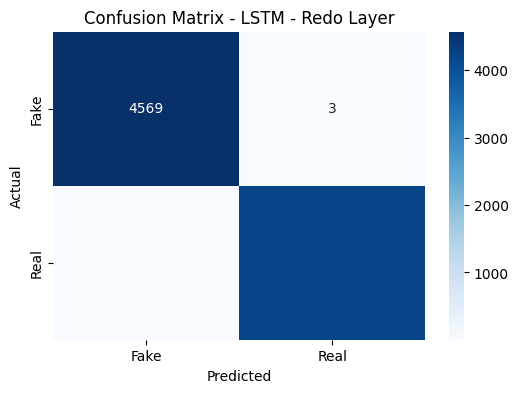

276/276 [==============================] - 9s 33ms/step


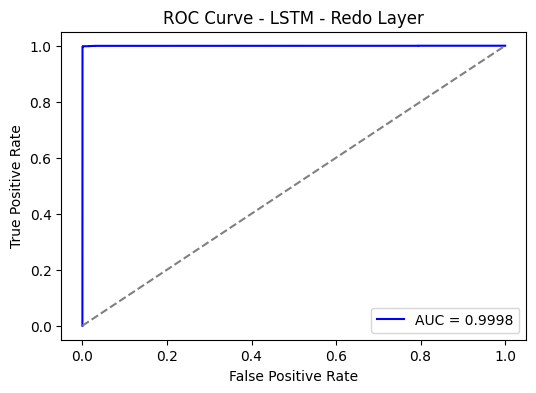

In [41]:
evaluate_model(lstm_model_redo, X_test, y_test)
plot_confusion_matrix(lstm_model_redo, X_test, y_test, "LSTM - Redo Layer")
plot_roc_curve(lstm_model_redo, X_test, y_test, "LSTM - Redo Layer")

Confusion Matrix will be improved in the final evaluation

In [42]:
lstm_pred_redo = lstm_model_redo.predict(padded_sample)
lstm_prob_redo = lstm_pred_redo[0][0]  
threshold = 0.5

# LSTM Model Prediction
if lstm_prob_redo >= threshold:
    lstm_result_redo = "Real"
    lstm_confidence_redo = lstm_prob_redo * 100  # Confidence in Real
else:
    lstm_result_redo = "Fake"
    lstm_confidence_redo = (1 - lstm_prob_redo) * 100  # Confidence in Fake

print(f"LSTM Prediction (Redo): {lstm_result_redo} (Confidence: {lstm_confidence_redo:.2f}%)")

1/1 [==============================] - 0s 37ms/step
LSTM Prediction (Redo): Fake (Confidence: 99.92%)


### Although we attempted to make the model better, it inadvertedly caused it to predict the true sentence as false.
### To find out why this is the case, we use LIME to identify which words the models focus on that determine its prediction.

In [ ]:
import lime
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(class_names=['Fake', 'Real'])

def lstm_predict(texts):
    # Tokenize and pad input texts
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    # Predict probabilities
    return lstm_model.predict(padded, verbose=0)

exp = explainer.explain_instance(
    "Head of a conservative Republican faction in the U.S. Congress urged budget restraint in 2019",
    lstm_predict, 
    num_features=10, 
    top_labels=1
)
exp.show_in_notebook(text=True)

In [ ]:
def lstm_redo_predict(texts):
    # Tokenize and pad input texts
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    # Predict probabilities
    return lstm_model_redo.predict(padded, verbose=0)

exp = explainer.explain_instance(
    "Head of a conservative Republican faction in the U.S. Congress urged budget restraint in 2019",
    lstm_redo_predict, 
    num_features=10, 
    top_labels=1
)
exp.show_in_notebook(text=True)

In [ ]:
def cnn_lstm_predict_proba(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    preds = cnn_lstm_model.predict(padded, verbose=0)
    return np.hstack([1 - preds, preds])  

exp = explainer.explain_instance(
    "Head of a conservative Republican faction in the U.S. Congress urged budget restraint in 2019", 
    cnn_lstm_predict_proba, 
    num_features=10,
    top_labels=1
)
exp.show_in_notebook(text=True)

In [ ]:
# Test on another true statement
sample_text_B=["North Korean leader Kim Jong Un sent a rare congratulatory message to Chinese President Xi Jinping on Wednesday at the end of China’s Communist Party Congress, wishing him 'great success' as head of the nation, the North’s state media said."]
sequence_B = tokenizer.texts_to_sequences(sample_text_B)
padded_sampleB = pad_sequences(sequence_B, maxlen=max_length, padding='post', truncating='post')


lstm_pred_B = lstm_model.predict(padded_sampleB)

print("CNN-LSTM Max Layer Prediction:", "Fake" if lstm_pred_B[0][0] < 0.5 else "Real")

if lstm_pred_B[0][0] >= 0.5:
    print("LSTM Prediction: REAL NEWS (confidence: {:.2f}%)".format(lstm_pred_B[0][0] * 100))
else:
    print("LSTM Prediction: FAKE NEWS (confidence: {:.2f}%)".format((1 - lstm_pred_B[0][0]) * 100))


lstm_pred_redoB = lstm_model_redo.predict(padded_sampleB)

print("LSTM Redo Prediction:", "Fake" if lstm_pred_redoB[0][0] < 0.5 else "Real")

if lstm_pred_redoB[0][0] >= 0.5:
    print("LSTM Redo Prediction: REAL NEWS (confidence: {:.2f}%)".format(lstm_pred_redoB[0][0] * 100))
else:
    print("LSTM Redo Prediction: FAKE NEWS (confidence: {:.2f}%)".format((1 - lstm_pred_redoB[0][0]) * 100))


cnn_lstm_B_pred = cnn_lstm_model.predict(padded_sampleB)

print("CNN-LSTM Max Layer Prediction:", "Fake" if cnn_lstm_B_pred[0][0] < 0.5 else "Real")

if cnn_lstm_B_pred[0][0] >= 0.5:
    print("CNN-LSTM Prediction: REAL NEWS (confidence: {:.2f}%)".format(cnn_lstm_B_pred[0][0] * 100))
else:
    print("CNN-LSTM Prediction: FAKE NEWS (confidence: {:.2f}%)".format((1 - cnn_lstm_B_pred[0][0]) * 100))

1/1 [==============================] - 0s 33ms/step
CNN-LSTM Max Layer Prediction: Fake
LSTM Prediction: FAKE NEWS (confidence: 59.84%)
1/1 [==============================] - 0s 45ms/step
LSTM Redo Prediction: Fake
LSTM Redo Prediction: FAKE NEWS (confidence: 99.97%)
1/1 [==============================] - 0s 25ms/step
CNN-LSTM Max Layer Prediction: Real
CNN-LSTM Prediction: REAL NEWS (confidence: 98.99%)


In [ ]:
from collections import defaultdict
import numpy as np

# Dictionary to store cumulative feature importance scores
word_importance = defaultdict(float)

# Select 100 random samples from dataset 
num_samples = 100
sample_texts = X_test[:num_samples]  
sample_texts = [text.decode('utf-8') if isinstance(text, bytes) else text for text in X_test[:num_samples]]


# Run LIME on each sample
for text in sample_texts:
    exp = explainer.explain_instance(text, lstm_predict, num_features=10, top_labels=1)
    label = exp.top_labels[0]  
    feature_importance = exp.as_list(label=label)  

    # Accumulate importance scores across samples
    for word, weight in feature_importance:
        word_importance[word] += weight

# Normalize by the number of samples
for word in word_importance:
    word_importance[word] /= num_samples



In [85]:
# Sort words by importance score (absolute value for ranking)
sorted_words = sorted(word_importance.items(), key=lambda x: abs(x[1]), reverse=True)[:15]  # Top 15 words

print("Top contributing words in LSTM across 100 samples (LIME):")
for word, weight in sorted_words:
    print(f"{word}: {weight:.4f}")


Top contributing words in LSTM across 100 samples (LIME):
Trump: -0.0002
that: -0.0001
story: 0.0001
following: 0.0001
you: -0.0000
of: 0.0000
Person: -0.0000
is: -0.0000
now: -0.0000
Tuesday: -0.0000
yesterday: -0.0000
incorrect: -0.0000
likely: 0.0000
Obama: -0.0000
One: -0.0000


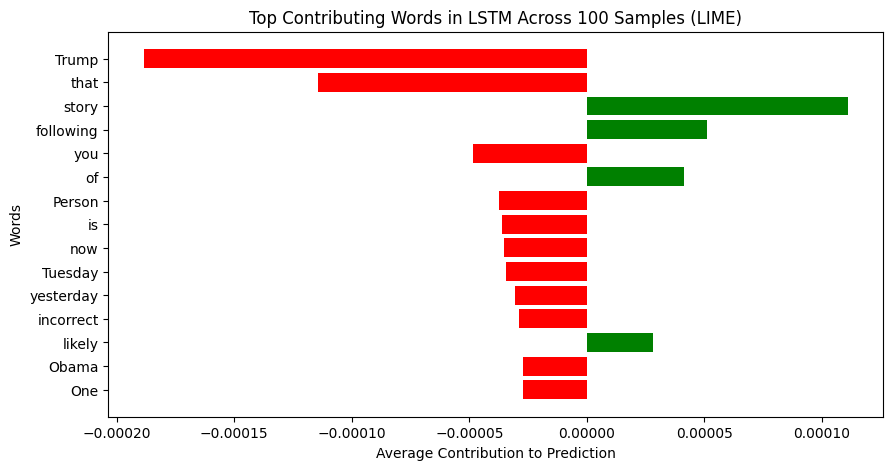

In [ ]:
import matplotlib.pyplot as plt

# Extract words and their weights for plotting
words, weights = zip(*sorted_words)

# Create bar plot
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color=['green' if w > 0 else 'red' for w in weights])
plt.xlabel("Average Contribution to Prediction")
plt.ylabel("Words")
plt.title("Top Contributing Words in LSTM Across 100 Samples (LIME)")
plt.gca().invert_yaxis()  
plt.show()


In [87]:
import pandas as pd

# Convert to a DataFrame
df = pd.DataFrame(sorted_words, columns=['Word', 'Importance'])

# Saving top words to CSV for later use
df.to_csv("LSTM_lime_word_importance.csv", index=False)

print("Saved to LSTM_lime_word_importance.csv")


Saved to LSTM_lime_word_importance.csv


In [ ]:
for text in sample_texts:
    exp = explainer.explain_instance(text, cnn_lstm_predict_proba, num_features=10, top_labels=1)
    label = exp.top_labels[0]  
    feature_importance = exp.as_list(label=label)  

    # Accumulate importance scores across samples
    for word, weight in feature_importance:
        word_importance[word] += weight

# Normalize by the number of samples
for word in word_importance:
    word_importance[word] /= num_samples



In [ ]:
# Sort words by importance score (absolute value for ranking)
sorted_words = sorted(word_importance.items(), key=lambda x: abs(x[1]), reverse=True)[:15]  
# Top 15 words

print("Top contributing words in CNN-LSTM across 100 samples (LIME):")
for word, weight in sorted_words:
    print(f"{word}: {weight:.4f}")


Top contributing words in CNN-LSTM across 100 samples (LIME):
s: 0.0033
the: 0.0032
Trump: 0.0029
that: 0.0028
said: -0.0026
Obama: 0.0014
Duterte: -0.0013
Mr: 0.0011
pic: 0.0009
Philippines: -0.0009
com: 0.0008
t: 0.0008
on: -0.0008
us: 0.0007
you: 0.0006


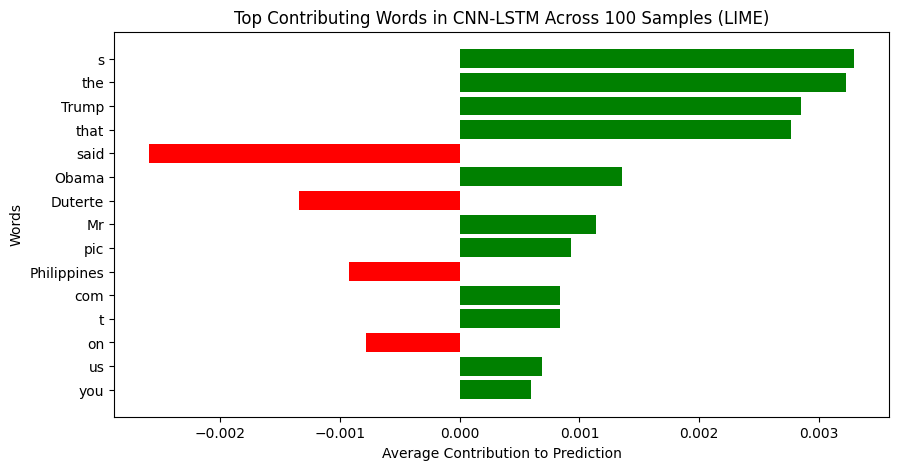

In [ ]:
import matplotlib.pyplot as plt

words, weights = zip(*sorted_words)

plt.figure(figsize=(10, 5))
plt.barh(words, weights, color=['green' if w > 0 else 'red' for w in weights])
plt.xlabel("Average Contribution to Prediction")
plt.ylabel("Words")
plt.title("Top Contributing Words in CNN-LSTM Across 100 Samples (LIME)")
plt.gca().invert_yaxis()
plt.show()


In [91]:
import pandas as pd

# Convert to a DataFrame
df = pd.DataFrame(sorted_words, columns=['Word', 'Importance'])

# Saving top words to CSV for later use
df.to_csv("CNN_LSTM_lime_word_importance.csv", index=False)

print("Saved to CNN_LSTM_lime_word_importance.csv")

Saved to CNN_LSTM_lime_word_importance.csv


In [ ]:
for text in sample_texts:
    exp = explainer.explain_instance(text, lstm_redo_predict, num_features=10, top_labels=1)
    label = exp.top_labels[0]  
    feature_importance = exp.as_list(label=label)  

    for word, weight in feature_importance:
        word_importance[word] += weight

for word in word_importance:
    word_importance[word] /= num_samples


In [ ]:
sorted_words = sorted(word_importance.items(), key=lambda x: abs(x[1]), reverse=True)[:15]  

print("Top contributing words in LSTM (Redo) across 100 samples (LIME):")
for word, weight in sorted_words:
    print(f"{word}: {weight:.4f}")


Top contributing words in LSTM (Redo) across 100 samples (LIME):
the: 0.0001
yesterday: -0.0001
Palace: 0.0001
Prince: 0.0001
s: -0.0001
announced: -0.0001
A: -0.0000
prayers: 0.0000
Maybe: -0.0000
Trump: -0.0000
thoughts: -0.0000
of: 0.0000
Harry: -0.0000
that: 0.0000
said: -0.0000


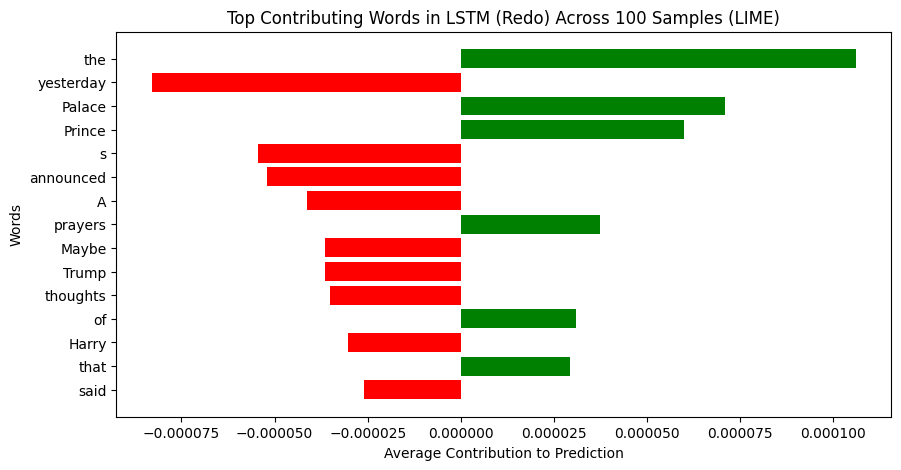

In [ ]:
import matplotlib.pyplot as plt

words, weights = zip(*sorted_words)

# Create bar plot
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color=['green' if w > 0 else 'red' for w in weights])
plt.xlabel("Average Contribution to Prediction")
plt.ylabel("Words")
plt.title("Top Contributing Words in LSTM (Redo) Across 100 Samples (LIME)")
plt.gca().invert_yaxis()  
plt.show()


Attempt to improve CNN+LSTM model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Bidirectional, LSTM, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU

def build_better_cnn_lstm_model():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_length),

        # First Convolutional Block
        Conv1D(filters=128, kernel_size=5, padding='same'),
        BatchNormalization(),
        LeakyReLU(),
        Conv1D(filters=128, kernel_size=5, padding='same'),
        BatchNormalization(),
        LeakyReLU(),
        MaxPooling1D(pool_size=2), 

        Conv1D(filters=128, kernel_size=5, padding='same'),
        BatchNormalization(),
        LeakyReLU(),
        MaxPooling1D(pool_size=2),

        # LSTM Layers
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),  
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3)),

        # Fully Connected Layers
        Dense(128),
        BatchNormalization(),
        LeakyReLU(),
        Dropout(0.3),

        Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
cnn_lstm_model_redo = build_better_cnn_lstm_model()

cnn_lstm_model_redo.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]  
)

Epoch 1/50
1102/1102 [==============================] - 47s 37ms/step - loss: 0.0198 - accuracy: 0.9936 - val_loss: 0.0077 - val_accuracy: 0.9986
Epoch 2/50
1102/1102 [==============================] - 39s 36ms/step - loss: 0.0073 - accuracy: 0.9982 - val_loss: 0.0062 - val_accuracy: 0.9993
Epoch 3/50
1102/1102 [==============================] - 39s 36ms/step - loss: 0.0037 - accuracy: 0.9991 - val_loss: 0.0103 - val_accuracy: 0.9980
Epoch 4/50
1102/1102 [==============================] - 39s 36ms/step - loss: 0.0031 - accuracy: 0.9993 - val_loss: 0.0111 - val_accuracy: 0.9981
Epoch 5/50
1102/1102 [==============================] - 39s 36ms/step - loss: 0.0040 - accuracy: 0.9990 - val_loss: 0.0068 - val_accuracy: 0.9988


276/276 [==============================] - 5s 12ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4572
           1       1.00      1.00      1.00      4240

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812

276/276 [==============================] - 3s 12ms/step


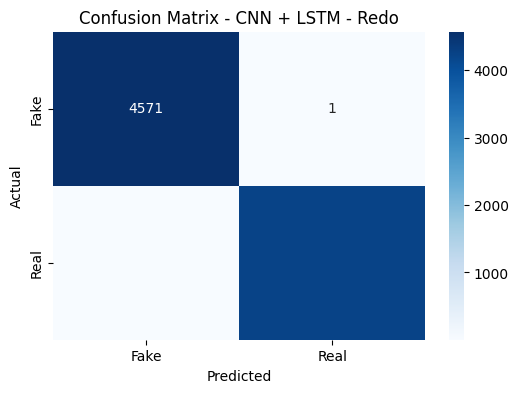

276/276 [==============================] - 3s 11ms/step


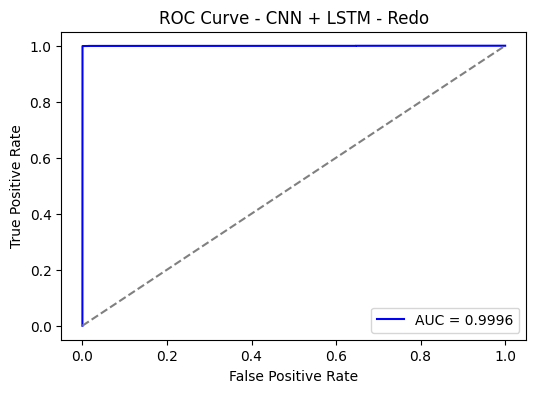

In [103]:
evaluate_model(cnn_lstm_model_redo, X_test, y_test)
plot_confusion_matrix(cnn_lstm_model_redo, X_test, y_test, "CNN + LSTM - Redo")
plot_roc_curve(cnn_lstm_model_redo, X_test, y_test, "CNN + LSTM - Redo")

In [108]:
cnn_lstm_redo_pred = cnn_lstm_model_redo.predict(padded_sample)

print("CNN-LSTM Redo Prediction:", "Fake" if cnn_lstm_redo_pred[0][0] < 0.5 else "Real")

if cnn_lstm_redo_pred[0][0] >= 0.5:
    print("CNN-LSTM Redo Prediction: REAL NEWS (confidence: {:.2f}%)".format(cnn_lstm_redo_pred[0][0] * 100))
else:
    print("CNN-LSTM Redo Prediction: FAKE NEWS (confidence: {:.2f}%)".format((1 - cnn_lstm_redo_pred[0][0]) * 100))

1/1 [==============================] - 0s 36ms/step
CNN-LSTM Redo Prediction: Fake
CNN-LSTM Redo Prediction: FAKE NEWS (confidence: 94.13%)


In [ ]:
def cnn_lstm_redo_predict_proba(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    preds = cnn_lstm_model_redo.predict(padded, verbose=0)
    return np.hstack([1 - preds, preds])  

exp = explainer.explain_instance(
    "Head of a conservative Republican faction in the U.S. Congress urged budget restraint in 2019", 
    cnn_lstm_redo_predict_proba, 
    num_features=10,
    top_labels=1
)
exp.show_in_notebook(text=True)

### Despite attempts to improve the models, the original version of the models seem to predict our true example correctly.
Thus the base version of the models will be used in our application

In [ ]:
lstm_model.save("lstm_FINAL.keras")

cnn_lstm_model.save("cnn_lstm_FINAL.keras")